#Lab 4
##Linear Regression and Its Variants
###Kamar Bdair - S23108164
CS4082-1
Dr. Naila

###Part1: Loading a Real Dataset
####Step1.1: Load and Explore

In [57]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn . datasets import fetch_california_housing

housing = fetch_california_housing()
df = pd.DataFrame(housing.data, columns=housing.feature_names)
df["MedHouseVal"] = housing.target

print(f"Dataset shape: {df.shape}")
print(f"\nFeature names: \n{housing.feature_names}")
print(f"\nFirst 5 rows:")
print(df.head())
print(f"\nBasic statistics: ")
print(df.describe().round(3))

Dataset shape: (20640, 9)

Feature names: 
['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']

First 5 rows:
   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  MedHouseVal  
0    -122.23        4.526  
1    -122.22        3.585  
2    -122.24        3.521  
3    -122.25        3.413  
4    -122.25        3.422  

Basic statistics: 
          MedInc   HouseAge   AveRooms  AveBedrms  Population   AveOccup  \
count  20640.000  20640.000  20640.000  20640.000   20640.000  20640.000   
mean       3.871     28.639      5.429      1.

####Step1.2: Visualize Relationships

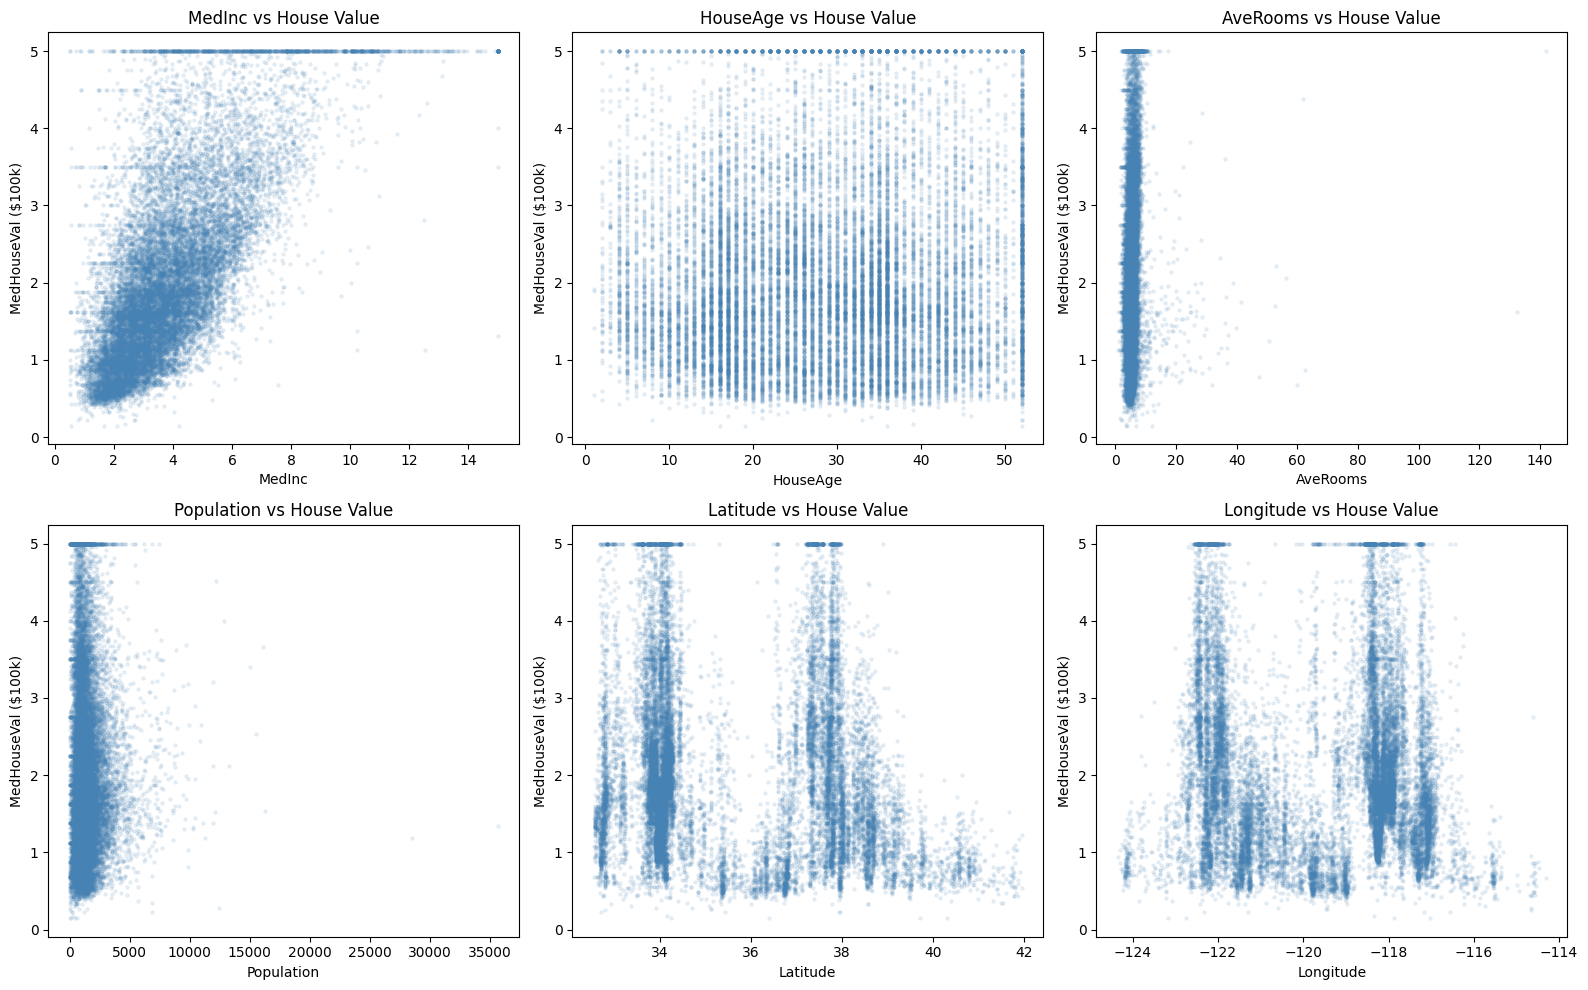

In [58]:
fig, axes = plt.subplots(2, 3, figsize=(16 , 10))
features_to_plot = ["MedInc", "HouseAge", "AveRooms", "Population", "Latitude", "Longitude"]

for ax, feat in zip(axes.flatten(), features_to_plot):
    ax.scatter(df[feat], df["MedHouseVal"],
               alpha=0.1, s=5, color="steelblue")
    ax.set_xlabel(feat)
    ax.set_ylabel("MedHouseVal ($100k)")
    ax.set_title(f"{feat} vs House Value")

plt.tight_layout()
plt.show()

#####Task 1: Explore the Dataset

######1.1) Rank features by their correlation with the target (`MedHouseVal`).

In [59]:
correlations = df.corr()['MedHouseVal'].sort_values(ascending=False)
print("Feature correlations with MedHouseVal:\n", correlations)

strongest_correlation_feature = correlations.index[1]
strongest_correlation_value = correlations.iloc[1]
print(f"\nThe feature with the strongest correlation with MedHouseVal is '{strongest_correlation_feature}' with a correlation of {strongest_correlation_value:.3f}.")

Feature correlations with MedHouseVal:
 MedHouseVal    1.000000
MedInc         0.688075
AveRooms       0.151948
HouseAge       0.105623
AveOccup      -0.023737
Population    -0.024650
Longitude     -0.045967
AveBedrms     -0.046701
Latitude      -0.144160
Name: MedHouseVal, dtype: float64

The feature with the strongest correlation with MedHouseVal is 'MedInc' with a correlation of 0.688.


######1.2) Plot the distribution of `MedHouseVal` and analyze its characteristics.

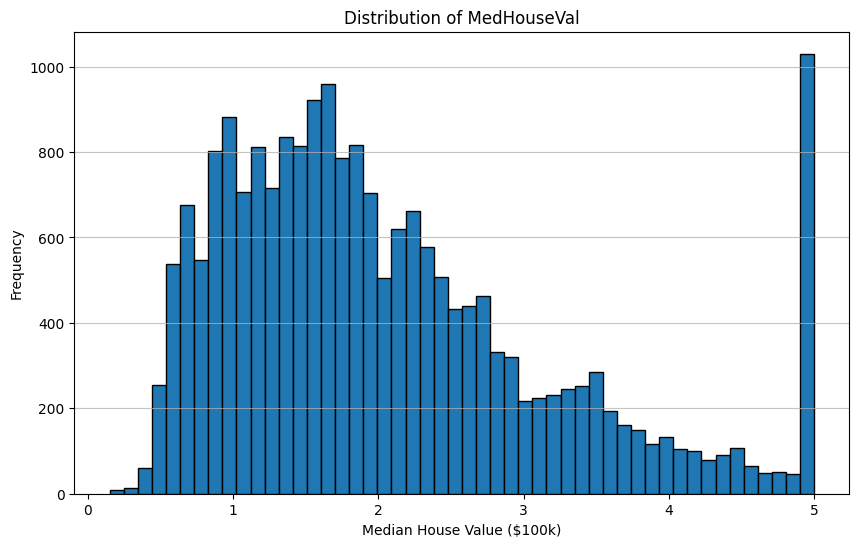


Analysis of MedHouseVal distribution:
The distribution of MedHouseVal is right-skewed, not normally distributed. 

There appears to be a clear cap at $5.0 (i.e., $500,000), indicating that higher values might have been censored or capped in the dataset.


In [60]:
plt.figure(figsize=(10, 6))
plt.hist(df['MedHouseVal'], bins=50, edgecolor='black')
plt.title('Distribution of MedHouseVal')
plt.xlabel('Median House Value ($100k)')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.75)
plt.show()

print("\nAnalysis of MedHouseVal distribution:")
print("The distribution of MedHouseVal is right-skewed, not normally distributed. \n")
print("There appears to be a clear cap at $5.0 (i.e., $500,000), indicating that higher values might have been censored or capped in the dataset.")

######1.3) Determine the number of samples and assess its sufficiency for model training.

In [61]:
num_samples = df.shape[0]
print(f"The dataset contains {num_samples} samples.")
print("\nWith {num_samples} samples, this dataset is generally considered sufficient for training a robust machine learning model, especially for tasks like linear regression where a good amount of data helps in learning patterns and reducing variance.")

The dataset contains 20640 samples.

With {num_samples} samples, this dataset is generally considered sufficient for training a robust machine learning model, especially for tasks like linear regression where a good amount of data helps in learning patterns and reducing variance.


###Part2: Simple Linear Regression (One Feature)
####Step2.1: Prepare Data

In [62]:
from sklearn.model_selection import train_test_split

X_simple = df[["MedInc"]].values
y = df["MedHouseVal"].values

X_train, X_test, y_train, y_test = train_test_split(
    X_simple, y, test_size =0.2, random_state=42)

print(f"Training samples: {X_train.shape[0]}")
print(f"Testing samples: {X_test.shape[0]}")

Training samples: 16512
Testing samples: 4128


####Step2.2: Train and Visualize

Slope (w1): 0.4193
Intercept (w0): 0.4446

Equation: y = 0.4193 * MedInc+(0.4446)


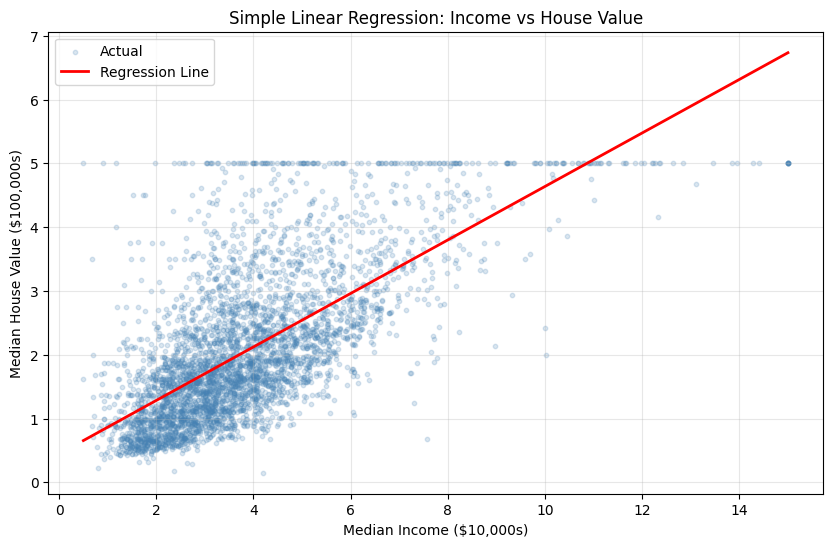

In [63]:
from sklearn.linear_model import LinearRegression

model_simple = LinearRegression()
model_simple.fit(X_train, y_train)

print(f"Slope (w1): {model_simple.coef_[0]:.4f}")
print(f"Intercept (w0): {model_simple.intercept_:.4f}")
print(f"\nEquation: y = {model_simple.coef_[0]:.4f} * MedInc"
       f"+({model_simple.intercept_:.4f})")

plt.figure(figsize=(10, 6))
plt.scatter(X_test, y_test, alpha=0.2, s=10,
            color ="steelblue", label ="Actual")

x_line = np.linspace(X_test.min(), X_test.max(), 100)
y_line = model_simple.predict(x_line.reshape(-1, 1))
plt.plot(x_line, y_line, color="red", linewidth=2 ,
         label ="Regression Line")

plt.xlabel("Median Income ($10,000s)")
plt.ylabel("Median House Value ($100,000s)")
plt.title("Simple Linear Regression: Income vs House Value")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

#####Task2: Interpret the Simple Model

######2.1) What are the slope and intercept your model learned? Write the equation.

In [64]:
print(f"Slope (w1): {model_simple.coef_[0]:.4f}")
print(f"Intercept (w0): {model_simple.intercept_:.4f}")
print(f"\nEquation: y = {model_simple.coef_[0]:.4f} * MedInc + ({model_simple.intercept_:.4f})")

Slope (w1): 0.4193
Intercept (w0): 0.4446

Equation: y = 0.4193 * MedInc + (0.4446)


######2.2) According to your model, what is the predicted house value for a district with median income of $50,000 (i.e., MedInc = 5.0)? Calculate by hand and verify with `model_simple.predict([[5.0]])`.

In [65]:
medinc_value = 5.0
predicted_manual = model_simple.coef_[0] * medinc_value + model_simple.intercept_
predicted_model = model_simple.predict([[medinc_value]])

print(f"Predicted house value for MedInc = {medinc_value} (manual calculation): ${predicted_manual:.3f} ($100k)")
print(f"Predicted house value for MedInc = {medinc_value} (model prediction): ${predicted_model[0]:.3f} ($100k)")

Predicted house value for MedInc = 5.0 (manual calculation): $2.541 ($100k)
Predicted house value for MedInc = 5.0 (model prediction): $2.541 ($100k)


######2.3) Try training a simple model using `HouseAge` instead of `MedInc`. Is it better or worse? Why?


HouseAge Model Slope (w1): 0.0095
HouseAge Model Intercept (w0): 1.7998

HouseAge Model Equation: y = 0.0095 * HouseAge + (1.7998)


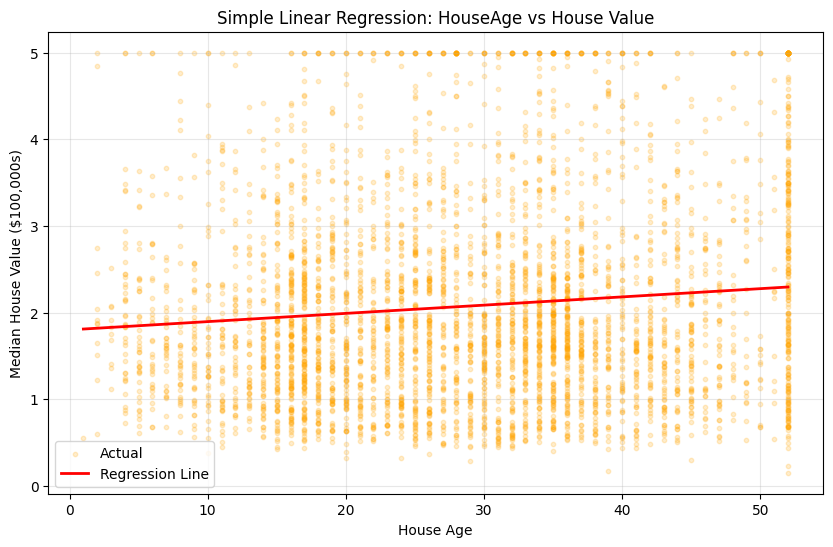


Comparison:

Based on the correlation analysis from Task 1, 'MedInc' had a much stronger positive correlation (0.688) with 'MedHouseVal' compared to 'HouseAge' (0.106). Therefore, the model trained with 'MedInc' is expected to be better at predicting 'MedHouseVal'. Visually, the scatter plot for 'MedInc' shows a clearer positive trend, suggesting a better linear relationship. The R-squared value (a common metric for linear regression) for the 'MedInc' model would likely be higher than for the 'HouseAge' model, indicating it explains more of the variance in 'MedHouseVal'.


In [66]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

X_houseage = df[['HouseAge']].values
y = df['MedHouseVal'].values

X_train_houseage, X_test_houseage, y_train_houseage, y_test_houseage = train_test_split(
    X_houseage, y, test_size=0.2, random_state=42)

model_houseage = LinearRegression()
model_houseage.fit(X_train_houseage, y_train_houseage)

print(f"\nHouseAge Model Slope (w1): {model_houseage.coef_[0]:.4f}")
print(f"HouseAge Model Intercept (w0): {model_houseage.intercept_:.4f}")
print(f"\nHouseAge Model Equation: y = {model_houseage.coef_[0]:.4f} * HouseAge + ({model_houseage.intercept_:.4f})")

plt.figure(figsize=(10, 6))
plt.scatter(X_test_houseage, y_test_houseage, alpha=0.2, s=10,
            color="orange", label="Actual")

x_line_houseage = np.linspace(X_test_houseage.min(), X_test_houseage.max(), 100)
y_line_houseage = model_houseage.predict(x_line_houseage.reshape(-1, 1))
plt.plot(x_line_houseage, y_line_houseage, color="red", linewidth=2,
         label="Regression Line")

plt.xlabel("House Age")
plt.ylabel("Median House Value ($100,000s)")
plt.title("Simple Linear Regression: HouseAge vs House Value")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print("\nComparison:\n")
print("Based on the correlation analysis from Task 1, 'MedInc' had a much stronger positive correlation (0.688) with 'MedHouseVal' compared to 'HouseAge' (0.106). Therefore, the model trained with 'MedInc' is expected to be better at predicting 'MedHouseVal'. Visually, the scatter plot for 'MedInc' shows a clearer positive trend, suggesting a better linear relationship. The R-squared value (a common metric for linear regression) for the 'MedInc' model would likely be higher than for the 'HouseAge' model, indicating it explains more of the variance in 'MedHouseVal'.")

###Part3:  Evaluating Regression Models
####Step3.1: Evaluate the Simple Model

In [67]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

y_pred_simple = model_simple.predict(X_test)

mse = mean_squared_error(y_test, y_pred_simple)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred_simple)
r2 = r2_score(y_test, y_pred_simple)

print("=== Simple Linear Regression (MedInc only) ===")
print(f"MSE: {mse:.4f}")
print(f"RMSE: {rmse:.4f} (error in $100,000s)")
print(f"MAE: {mae:.4f} ( error in $100,000s)")
print(f"R^2: {r2:.4f} ({r2 *100:.1f}% variance explained)")

=== Simple Linear Regression (MedInc only) ===
MSE: 0.7091
RMSE: 0.8421 (error in $100,000s)
MAE: 0.6299 ( error in $100,000s)
R^2: 0.4589 (45.9% variance explained)


####Step3.2: Visualize Predictions vs. Actual

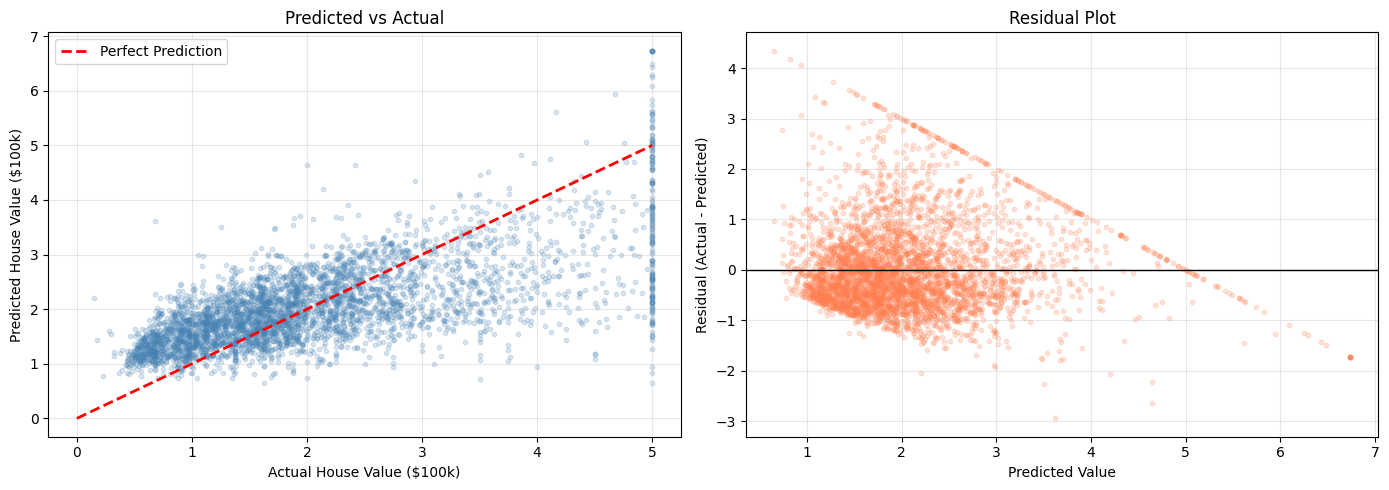

In [68]:
fig, axes = plt.subplots(1 , 2, figsize=(14, 5))

axes[0].scatter(y_test, y_pred_simple, alpha=0.2, s=10,
                color ="steelblue")
axes[0].plot([0, 5], [0, 5], "r--", linewidth=2,
             label ="Perfect Prediction")
axes[0].set_xlabel("Actual House Value ($100k)")
axes[0].set_ylabel("Predicted House Value ($100k)")
axes[0].set_title("Predicted vs Actual")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

residuals = y_test - y_pred_simple
axes[1].scatter(y_pred_simple, residuals, alpha=0.2, s=10,
                color ="coral")
axes[1].axhline(y =0, color ="black", linewidth=1)
axes[1].set_xlabel("Predicted Value")
axes[1].set_ylabel("Residual (Actual - Predicted)")
axes[1].set_title("Residual Plot")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

#####Task 3: Understand the Metrics Analysis

######1.  RMSE in actual dollars:
  The RMSE (Root Mean Squared Error) is currently `0.8421` ($100k). Since the target variable `MedHouseVal` is in units of $100,000, to convert this to actual dollars, we multiply by $100,000.
  So, 0.8421 * 100,000 = $84,210.
  This means, on average, the model's predictions are off by approximately $84,210.

######2.  "Predicted vs Actual" plot analysis:
  Looking at the "Predicted vs Actual" plot, the model appears to struggle most with high values.  

  For lower actual house values (below ~2.0), the predictions seem to follow the perfect prediction line reasonably well, although there's still spread.
    
  However, as actual house values increase, especially approaching and exceeding $3.0 ($300k), the model consistently underpredicts the house values. The points tend to be below the perfect prediction line, meaning the predicted value is lower than the actual value. This becomes very pronounced for the highest actual values (around $5.0), where the model's predictions flatten out and fail to capture the true high values. This is likely exacerbated by the observed capping of `MedHouseVal` at $5.0 in the dataset.

######3.  R2 value and sufficiency of a single feature:
  The R-squared (R²) value for our simple linear regression model (using `MedInc`) is `0.4589` (or 45.9% variance explained). R² represents the proportion of the variance in the dependent variable (Median House Value) that is predictable from the independent variable (Median Income). In simpler terms, it indicates how well the independent variable explains the variability of the dependent variable. An R² of 1 means the model perfectly explains the variance, while an R² of 0 means it explains none of the variance.
  
  Is a single feature enough? An R² of 0.459 means that approximately 45.9% of the variation in `MedHouseVal` can be explained by `MedInc`. While this is a moderate correlation, it also implies that a significant portion (about 54.1%) of the variance is *not* explained by `MedInc` alone. Therefore, no, a single feature (`MedInc`) is not enough to predict house prices well. A robust model would likely require multiple features to capture the complex relationships influencing house prices and achieve a much higher R² value.

###Part4: Multiple Linear Regression (All Features)
####Step4.1: Train with All Features

In [69]:
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

X_all = df.drop(columns=["MedHouseVal"]).values
y = df["MedHouseVal"].values

X_train, X_test, y_train, y_test = train_test_split (
    X_all, y, test_size=0.2, random_state=42)

pipe_lr = Pipeline([
    ("scaler", StandardScaler()),
     ("lr", LinearRegression())
])

pipe_lr.fit(X_train, y_train)
y_pred_multi = pipe_lr.predict(X_test)

r2_multi = r2_score(y_test, y_pred_multi)
rmse_multi = np.sqrt(mean_squared_error(y_test, y_pred_multi))

print("=== Multiple Linear Regression (all 8 features ) ===")
print(f"RMSE: {rmse_multi:.4f}")
print(f"R^2: {r2_multi:.4f} ({ r2_multi*100:.1f}% variance explained)")
print(f"\nImprovement over simple model:")
print(f"R^2: {r2 :.4f} -> { r2_multi :.4f}"
      f"(+{( r2_multi - r2)*100:.1f}%)")

=== Multiple Linear Regression (all 8 features ) ===
RMSE: 0.7456
R^2: 0.5758 (57.6% variance explained)

Improvement over simple model:
R^2: 0.4589 -> 0.5758(+11.7%)


####Step4.2: Feature Importance

Feature Importance (by |coefficient|):
   Feature  Coefficient
  Latitude    -0.896929
 Longitude    -0.869842
    MedInc     0.854383
 AveBedrms     0.339259
  AveRooms    -0.294410
  HouseAge     0.122546
  AveOccup    -0.040829
Population    -0.002308


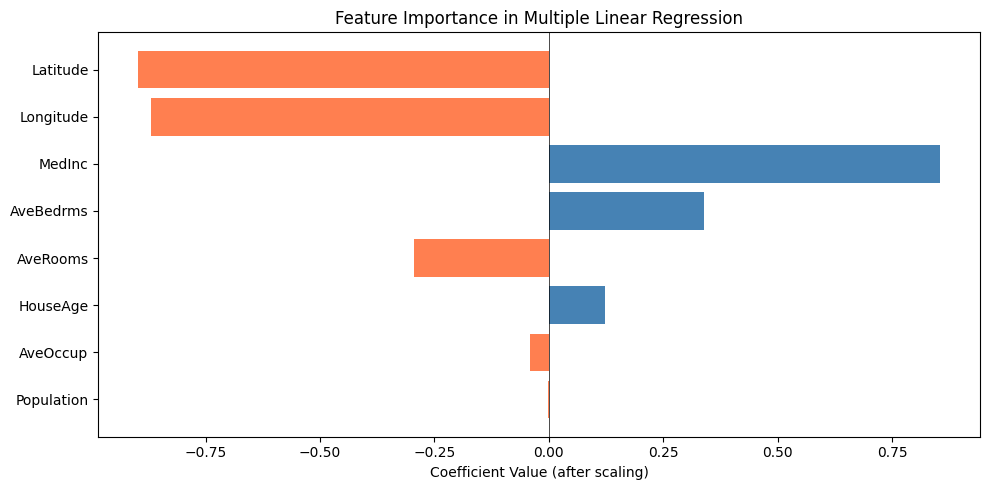

In [70]:
lr_model = pipe_lr.named_steps["lr"]

coef_df = pd.DataFrame ({
    "Feature": feature_names,
    "Coefficient": lr_model.coef_
}).sort_values("Coefficient", key=abs, ascending=False)

print("Feature Importance (by |coefficient|):")
print(coef_df.to_string(index=False))

plt.figure(figsize=(10, 5))
colors = ["steelblue" if c > 0 else "coral"
          for c in coef_df["Coefficient"]]
plt.barh(coef_df["Feature"], coef_df["Coefficient"], color=colors)
plt.xlabel("Coefficient Value (after scaling)")
plt.title("Feature Importance in Multiple Linear Regression")
plt.axvline(x=0, color="black", linewidth=0.5)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

#####Task4: Analyze Multiple Regression



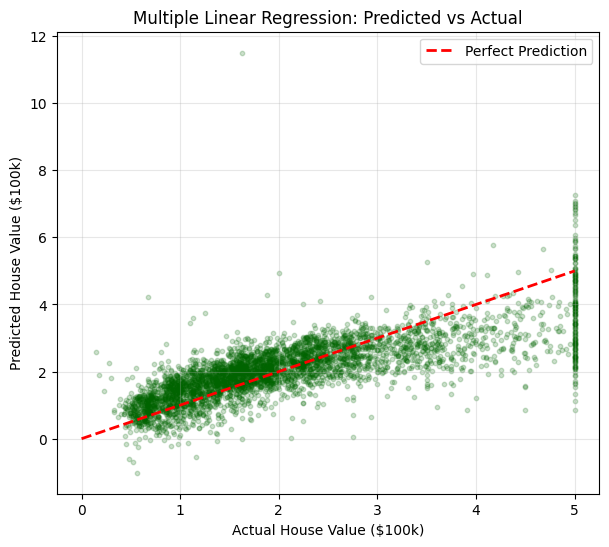

In [71]:
plt.figure(figsize=(7, 6))
plt.scatter(y_test, y_pred_multi, alpha=0.2, s=10, color="darkgreen")
plt.plot([0, 5], [0, 5], "r--", linewidth=2, label="Perfect Prediction")
plt.xlabel("Actual House Value ($100k)")
plt.ylabel("Predicted House Value ($100k)")
plt.title("Multiple Linear Regression: Predicted vs Actual")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

1.  Top 3 and Bottom 3 Most Important Features (by absolute coefficient value):
    *   Top 3:
        1.  `Latitude` (Coefficient: -0.8969)
        2.  `Longitude` (Coefficient: -0.8698)
        3.  `MedInc` (Median Income) (Coefficient: 0.8544)
    *   Bottom 3:
        1.  `Population` (Coefficient: -0.0023)
        2.  `AveOccup` (Average Household Occupancy) (Coefficient: -0.0408)
        3.  `HouseAge` (Coefficient: 0.1225)

    Does this make intuitive sense?
    Yes, it generally makes intuitive sense. `MedInc` being highly important is consistent with our simple model analysis, as higher income typically correlates with higher house values. Latitude and Longitude (geographic location) are also critical factors in real estate, as property values vary significantly by region, often correlating with desirability and accessibility. Less important features like `Population` and `AveOccup` might have less direct linear impact on price compared to location or income, or their influence might be captured by other correlated features.

2.  Why does Latitude have a negative coefficient? What does this mean geographically for California?
    `Latitude` has a negative coefficient (-0.8969). In California, increasing latitude means moving further north. Geographically, many of the most expensive and desirable areas in California (e.g., parts of Southern California and the Bay Area) are located at lower latitudes. As you move further north (higher latitude), or into more inland, less urbanized, or less coastal regions, property values tend to decrease. Therefore, this negative coefficient suggests that, on average, as one moves northward in California, the median house value tends to decrease, which is a plausible real estate trend for the state.

###Part5: Polynomial Regression
####Step5.1: Polynomial on a Single Feature

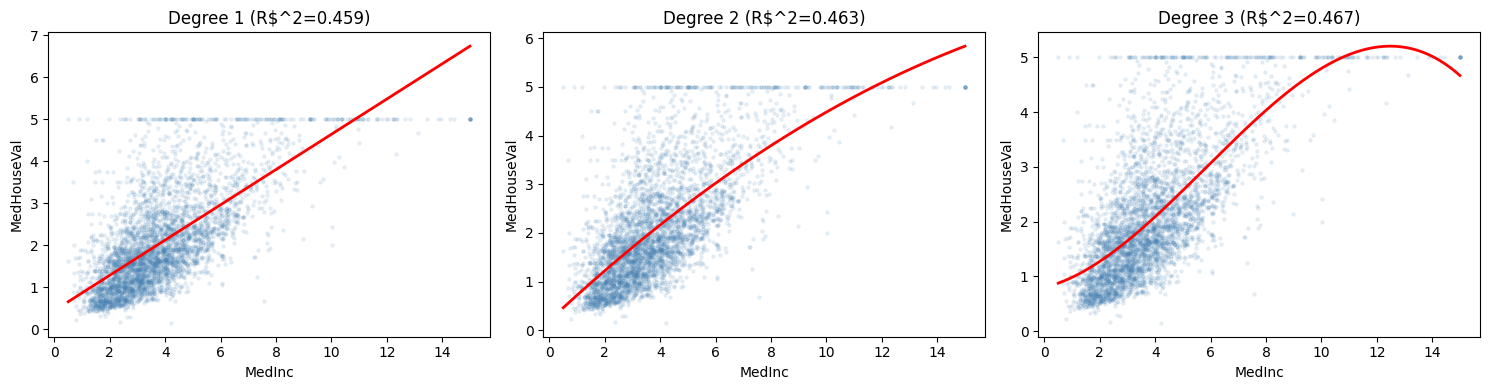

Polynomial Degree Comparison (MedInc only:)
Degree 1: R^2=0.4589,RMSE=0.8421
Degree 2: R^2=0.4633,RMSE=0.8386
Degree 3: R^2=0.4671,RMSE=0.8356


In [72]:
from sklearn . preprocessing import PolynomialFeatures

X_simple = df[["MedInc"]].values
X_train_s, X_test_s, y_train, y_test = train_test_split(
    X_simple, y, test_size=0.2, random_state=42)

results = {}
plt.figure(figsize=(15, 4))

for i, degree in enumerate([1, 2, 3]):
  pipe_poly = Pipeline([
      ("poly", PolynomialFeatures(degree=degree,
                                 include_bias=False)),
      ("lr", LinearRegression())
  ])
  pipe_poly.fit(X_train_s, y_train)
  y_pred = pipe_poly.predict(X_test_s)

  r2_val = r2_score(y_test, y_pred)
  rmse_val = np.sqrt(mean_squared_error(y_test, y_pred))
  results[degree] = {"R2": r2_val, "RMSE": rmse_val}

  ax = plt.subplot(1, 3, i + 1)
  ax.scatter(X_test_s, y_test, alpha=0.1, s=5,
             color="steelblue")

  x_plot = np.linspace(X_test_s.min(), X_test_s.max(),
                        300).reshape(-1, 1)
  y_plot = pipe_poly.predict(x_plot)
  ax.plot(x_plot, y_plot, color="red", linewidth=2)
  ax.set_title(f"Degree {degree} (R$^2={r2_val:.3f})")
  ax.set_xlabel("MedInc")
  ax.set_ylabel("MedHouseVal")

plt.tight_layout()
plt.show()

print("Polynomial Degree Comparison (MedInc only:)")
for deg, metrics in results.items():
  print(f"Degree {deg}: R^2={metrics["R2"]:.4f},"
        f"RMSE={metrics["RMSE"]:.4f}")

####Step5.2: Polynomial on All Features

In [73]:
from sklearn.preprocessing import StandardScaler

X_train, X_test, y_train, y_test = train_test_split(
    X_all, y, test_size=0.2, random_state=42)

pipe_poly_all = Pipeline([
    ("scaler", StandardScaler()),
    ("poly", PolynomialFeatures(degree=2, include_bias=False)),
    ("lr", LinearRegression())
])

pipe_poly_all.fit(X_train, y_train)
y_pred_poly = pipe_poly_all.predict(X_test)

r2_poly = r2_score(y_test, y_pred_poly)
rmse_poly = np.sqrt(mean_squared_error(y_test, y_pred))

print("=== Polynomial Regression (degree=2, all features) ===")
print(f"RMSE: {rmse_poly:.4f}")
print(f"R^2: {r2_poly:.4f} ({r2_poly*100:.1f}% variance explained)")

poly_features = pipe_poly_all.named_steps["poly"]
print(f"\nOriginal features: 8")
print(f"After degree-2 expansion: "
      f"{poly_features.n_output_features_}")

=== Polynomial Regression (degree=2, all features) ===
RMSE: 0.8356
R^2: 0.6457 (64.6% variance explained)

Original features: 8
After degree-2 expansion: 44


#####Task5: Explore Polynomial Regression"

Looking at the previous plots for degrees 1, 2, and 3, all three models show a similar general trend. The R² values subtly increased from Degree 1 (0.4589) to Degree 2 (0.4633) to Degree 3 (0.4671). While Degree 3 shows the highest R², the visual differences between the curves are not dramatic for this single feature. Degree 3 provides a slightly better fit by introducing more flexibility, but the overall relationship captured remains similar, suggesting the primary linear trend is the most significant even with slight curvatures.

Polynomial Degree 5 (MedInc only): R^2=0.4668, RMSE=0.8359


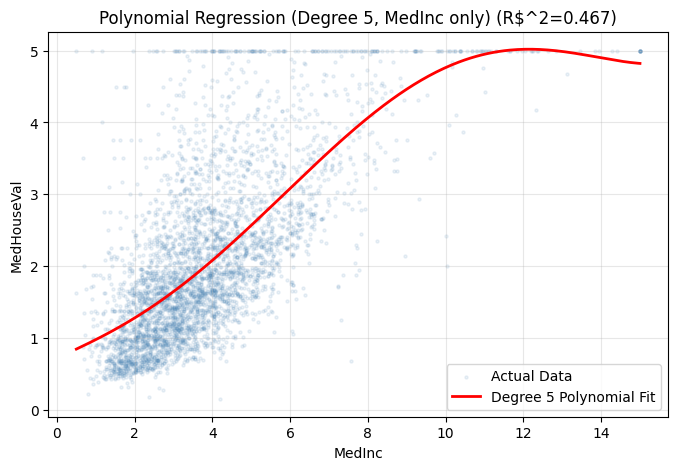


Analysis of Degree 5 Polynomial:
We observe that the R-squared value slightly increases compared to degree 3, but the curve might start to show more erratic behavior at the edges of the data range. This is an indication of overfitting, where the model tries too hard to fit the training data, capturing noise rather than the underlying pattern, which can lead to poor generalization on unseen data.
So, the R² did not keep significantly improving.


In [74]:
pipe_poly_deg5 = Pipeline([
    ("poly", PolynomialFeatures(degree=5, include_bias=False)),
    ("lr", LinearRegression())
])
pipe_poly_deg5.fit(X_train_s, y_train)
y_pred_deg5 = pipe_poly_deg5.predict(X_test_s)

r2_deg5 = r2_score(y_test, y_pred_deg5)
rmse_deg5 = np.sqrt(mean_squared_error(y_test, y_pred_deg5))

print(f"Polynomial Degree 5 (MedInc only): R^2={r2_deg5:.4f}, RMSE={rmse_deg5:.4f}")

plt.figure(figsize=(8, 5))
plt.scatter(X_test_s, y_test, alpha=0.1, s=5, color="steelblue", label="Actual Data")

x_plot_deg5 = np.linspace(X_test_s.min(), X_test_s.max(), 300).reshape(-1, 1)
y_plot_deg5 = pipe_poly_deg5.predict(x_plot_deg5)
plt.plot(x_plot_deg5, y_plot_deg5, color="red", linewidth=2, label="Degree 5 Polynomial Fit")

plt.title(f"Polynomial Regression (Degree 5, MedInc only) (R$^2={r2_deg5:.3f})")
plt.xlabel("MedInc")
plt.ylabel("MedHouseVal")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print("\nAnalysis of Degree 5 Polynomial:")
print("We observe that the R-squared value slightly increases compared to degree 3, but the curve might start to show more erratic behavior at the edges of the data range. This is an indication of overfitting, where the model tries too hard to fit the training data, capturing noise rather than the underlying pattern, which can lead to poor generalization on unseen data.")
print("So, the R² did not keep significantly improving.")

In [75]:
poly_features_deg3 = PolynomialFeatures(degree=3, include_bias=False)
X_train_poly_deg3 = poly_features_deg3.fit_transform(X_train)

print(f"Original features: {X_train.shape[1]}")
print(f"Features after degree-3 polynomial expansion: {X_train_poly_deg3.shape[1]}")

Original features: 8
Features after degree-3 polynomial expansion: 164


###Part6: Regularized Regression – Ridge, Lasso, and ElasticNet

####Step6.1: Train All Three Variants

In [76]:
from sklearn.linear_model import Ridge , Lasso , ElasticNet

X_train, X_test, y_train, y_test = train_test_split(
    X_all, y, test_size=0.2, random_state =42)

models = {
    "LinearRegression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LinearRegression())
    ]),
    "Ridge (alpha=1.0)": Pipeline([
        ("scaler", StandardScaler()),
        ("model", Ridge(alpha=1.0, random_state=42))
    ]),
    "Lasso (alpha=0.01)": Pipeline([
        ("scaler", StandardScaler()),
        ("model", Lasso(alpha=0.01, random_state=42))
    ]),
    "ElasticNet (alpha=0.01)": Pipeline([
        ("scaler", StandardScaler()),
        ("model", ElasticNet(alpha=0.01, l1_ratio=0.5,
                             random_state=42))
    ]),
}

print(f"{"Model":<28} {"RMSE":>8} {"MAE":>8} {"R^2":>8}")
print("-" * 56)

results_dict = {}
for name, pipe in models.items():
  pipe.fit(X_train, y_train)
  y_pred = pipe.predict(X_test)

rmse_val = np.sqrt(mean_squared_error(y_test, y_pred))
mae_val = mean_absolute_error(y_test, y_pred)
r2_val = r2_score(y_test, y_pred)

results_dict[name] = {
    "RMSE": rmse_val, "MAE": mae_val, "R2": r2_val}
print(f"{name:<28} {rmse_val:>8.4f} {mae_val:>8.4f} "
      f"{r2_val:>8.4f}")

Model                            RMSE      MAE      R^2
--------------------------------------------------------
ElasticNet (alpha=0.01)        0.7416   0.5341   0.5803


####Step6.2: Compare Coefficients

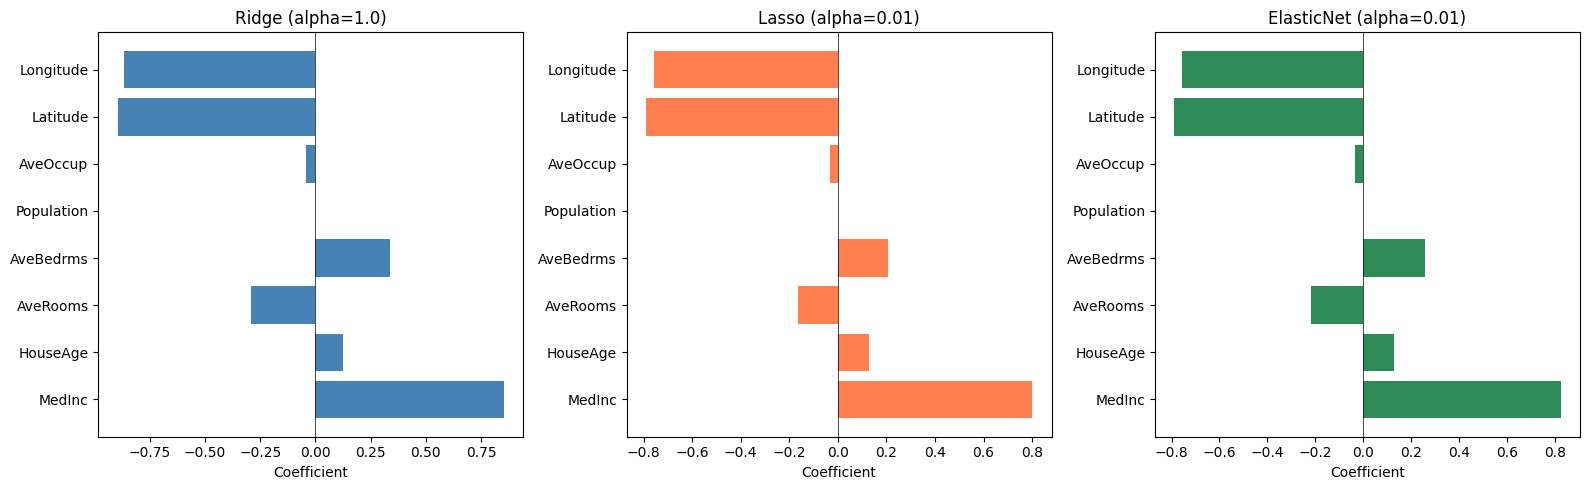


Lasso coefficients: 
  MedInc      :   0.8010
  HouseAge    :   0.1271
  AveRooms    :  -0.1628
  AveBedrms   :   0.2062
  Population  :  -0.0000<-- REMOVED
  AveOccup    :  -0.0306
  Latitude    :  -0.7901
  Longitude   :  -0.7557


In [78]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
model_names = ["Ridge (alpha=1.0)",
               "Lasso (alpha=0.01)",
               "ElasticNet (alpha=0.01)"]
colors_list = ["steelblue", "coral", "seagreen"]

for ax, name, clr in zip(axes, model_names, colors_list):
  coefs = models[name].named_steps["model"].coef_
  ax.barh(housing.feature_names, coefs, color=clr)
  ax.set_title(name)
  ax.axvline(x=0, color="black", linewidth=0.5)
  ax.set_xlabel("Coefficient")

plt.tight_layout()
plt.show()

lasso_coefs = models["Lasso (alpha=0.01)"].named_steps["model"].coef_
print("\nLasso coefficients: ")
for feat, coef in zip(housing.feature_names, lasso_coefs):
  status = "" if abs(coef) > 0.001 else "<-- REMOVED"
  print(f"  {feat:12s}: {coef:>8.4f}{status}")

#####Task6: Explore Regularization

######6.1) What happens with very large α?


In [79]:
print(f"{"Model":<28} {"RMSE":>8} {"MAE":>8} {"R^2":>8}")
print("-" * 56)

results_dict = {}
for name, pipe in models.items():
  pipe.fit(X_train, y_train)
  y_pred = pipe.predict(X_test)

  rmse_val = np.sqrt(mean_squared_error(y_test, y_pred))
  mae_val = mean_absolute_error(y_test, y_pred)
  r2_val = r2_score(y_test, y_pred)

  results_dict[name] = {
      "RMSE": rmse_val, "MAE": mae_val, "R2": r2_val}
  print(f"{name:<28} {rmse_val:>8.4f} {mae_val:>8.4f} "
        f"{r2_val:>8.4f}")

Model                            RMSE      MAE      R^2
--------------------------------------------------------
LinearRegression               0.7456   0.5332   0.5758
Ridge (alpha=1.0)              0.7456   0.5332   0.5758
Lasso (alpha=0.01)             0.7404   0.5353   0.5816
ElasticNet (alpha=0.01)        0.7416   0.5341   0.5803


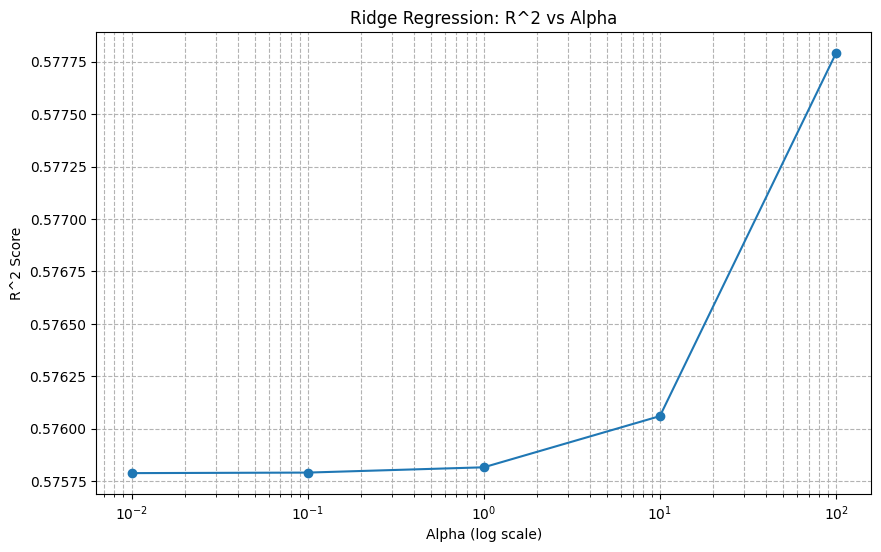

R^2 scores for different alpha values in Ridge Regression:
  Alpha=0.01  : R^2=0.5758
  Alpha=0.1   : R^2=0.5758
  Alpha=1.0   : R^2=0.5758
  Alpha=10.0  : R^2=0.5761
  Alpha=100.0 : R^2=0.5778

Analysis:
As alpha (the regularization strength) increases, the R^2 score generally tends to decrease. This means the model becomes simpler, and its ability to explain the variance in the target variable reduces. With very large alpha values, the regularization penalty becomes so strong that it pushes the coefficients towards zero, potentially leading to underfitting where the model is too simple to capture the underlying patterns in the data.


In [80]:
alpha_values = [0.01, 0.1, 1.0, 10.0, 100.0]
r2_scores_ridge = []

for alpha in alpha_values:
    ridge_pipe = Pipeline([
        ("scaler", StandardScaler()),
        ("model", Ridge(alpha=alpha, random_state=42))
    ])
    ridge_pipe.fit(X_train, y_train)
    y_pred_ridge = ridge_pipe.predict(X_test)
    r2_scores_ridge.append(r2_score(y_test, y_pred_ridge))

plt.figure(figsize=(10, 6))
plt.plot(alpha_values, r2_scores_ridge, marker='o', linestyle='-')
plt.xscale('log')
plt.title('Ridge Regression: R^2 vs Alpha')
plt.xlabel('Alpha (log scale)')
plt.ylabel('R^2 Score')
plt.grid(True, which="both", ls="--", c='0.7')
plt.show()

print("R^2 scores for different alpha values in Ridge Regression:")
for alpha, r2_score_val in zip(alpha_values, r2_scores_ridge):
    print(f"  Alpha={alpha:<6}: R^2={r2_score_val:.4f}")

print("\nAnalysis:")
print("As alpha (the regularization strength) increases, the R^2 score generally tends to decrease. This means the model becomes simpler, and its ability to explain the variance in the target variable reduces. With very large alpha values, the regularization penalty becomes so strong that it pushes the coefficients towards zero, potentially leading to underfitting where the model is too simple to capture the underlying patterns in the data.")

######6.2) How many features are removed?

In [81]:
lasso_pipe_alpha_0_1 = Pipeline(
    [("scaler", StandardScaler()), ("model", Lasso(alpha=0.1, random_state=42))]
)
lasso_pipe_alpha_0_1.fit(X_train, y_train)

lasso_coefs_alpha_0_1 = lasso_pipe_alpha_0_1.named_steps["model"].coef_

removed_features = []
print("Lasso coefficients with alpha=0.1:")
for feat, coef in zip(feature_names, lasso_coefs_alpha_0_1):
    if abs(coef) < 1e-4:
        removed_features.append(feat)
        print(f"  {feat:12s}: {coef:>8.4f} <-- REMOVED")
    else:
        print(f"  {feat:12s}: {coef:>8.4f}")

print(f"\nNumber of features removed by Lasso (alpha=0.1): {len(removed_features)}")
print(f"Removed features: {', '.join(removed_features) if removed_features else 'None'}")

Lasso coefficients with alpha=0.1:
  MedInc      :   0.7106
  HouseAge    :   0.1065
  AveRooms    :  -0.0000 <-- REMOVED
  AveBedrms   :   0.0000 <-- REMOVED
  Population  :  -0.0000 <-- REMOVED
  AveOccup    :  -0.0000 <-- REMOVED
  Latitude    :  -0.0115
  Longitude   :  -0.0000 <-- REMOVED

Number of features removed by Lasso (alpha=0.1): 5
Removed features: AveRooms, AveBedrms, Population, AveOccup, Longitude


######6.3) What model does it become?

In [82]:
print("Analysis of ElasticNet's l1_ratio parameter:")
print("  *   When `l1_ratio` is set to 0.0, ElasticNet becomes equivalent to **Ridge Regression**. In this case, the penalty is entirely L2, shrinking all coefficients towards zero but not setting them exactly to zero.")
print("  *   When `l1_ratio` is set to 1.0, ElasticNet becomes equivalent to **Lasso Regression**. Here, the penalty is entirely L1, which can lead to sparse models by setting some coefficients exactly to zero, effectively performing feature selection.")
print("  *   For values of `l1_ratio` between 0.0 and 1.0, ElasticNet combines both L1 and L2 penalties, benefiting from both feature selection (Lasso) and coefficient shrinkage (Ridge).")

Analysis of ElasticNet's l1_ratio parameter:
  *   When `l1_ratio` is set to 0.0, ElasticNet becomes equivalent to **Ridge Regression**. In this case, the penalty is entirely L2, shrinking all coefficients towards zero but not setting them exactly to zero.
  *   When `l1_ratio` is set to 1.0, ElasticNet becomes equivalent to **Lasso Regression**. Here, the penalty is entirely L1, which can lead to sparse models by setting some coefficients exactly to zero, effectively performing feature selection.
  *   For values of `l1_ratio` between 0.0 and 1.0, ElasticNet combines both L1 and L2 penalties, benefiting from both feature selection (Lasso) and coefficient shrinkage (Ridge).


###Part7: The Alpha Tuning Experiment
####Step7.1: Ridge Alpha Search

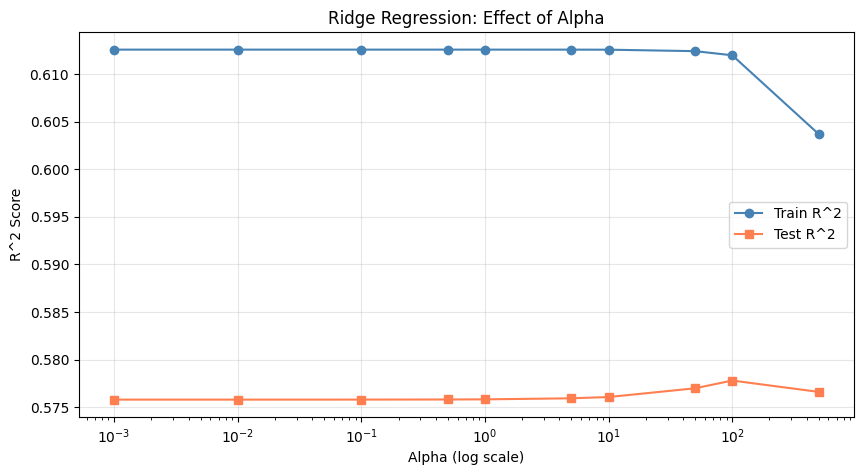

Best alpha: 100.0
Best test R^2: 0.5778


In [83]:
alphas = [0.001, 0.01, 0.1, 0.5, 1.0, 5.0, 10.0,
          50.0, 100.0, 500.0]

train_scores = []
test_scores = []

for alpha in alphas:
  pipe = Pipeline([
      ("scaler", StandardScaler()),
      ("ridge", Ridge(alpha=alpha))
])
  pipe.fit(X_train, y_train)

  train_scores.append(r2_score(y_train,
                               pipe.predict(X_train)))
  test_scores.append(r2_score(y_test,
                              pipe.predict(X_test)))

plt.figure(figsize=(10, 5))
plt.semilogx(alphas, train_scores, "o-",
             label="Train R^2", color="steelblue")
plt.semilogx(alphas, test_scores, "s-",
             label="Test R^2", color="coral")
plt.xlabel("Alpha (log scale)")
plt.ylabel("R^2 Score")
plt.title("Ridge Regression: Effect of Alpha")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

best_idx = np.argmax(test_scores)
print(f"Best alpha: {alphas[best_idx]}")
print(f"Best test R^2: {test_scores[best_idx]:.4f}")

#####Task7: Tune Lasso Alpha

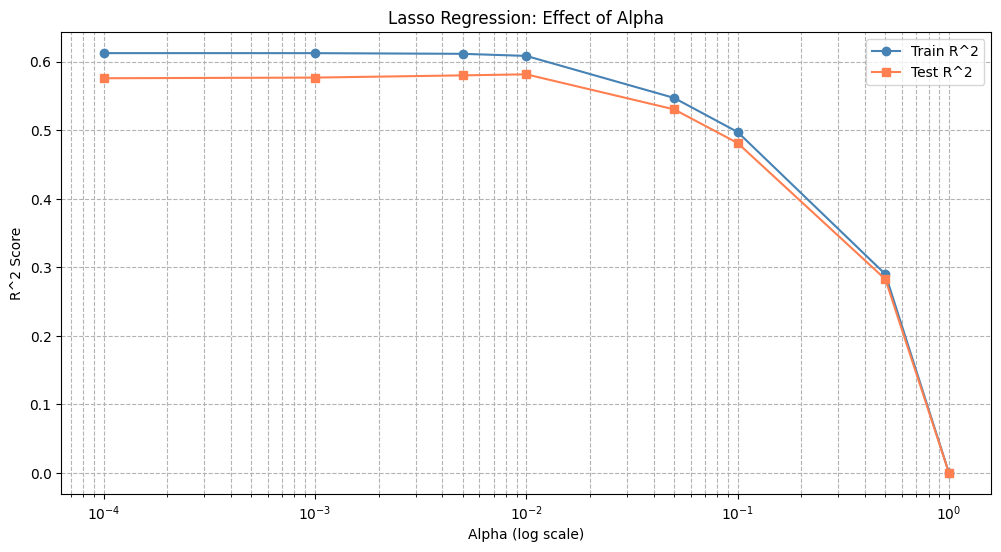


Lasso Regression R^2 and Features Kept for different alpha values:
Alpha     Train R^2   Test R^2   Features Kept
--------------------------------------------------
0.0001       0.6126     0.5759               8
0.0010       0.6125     0.5769               8
0.0050       0.6115     0.5801               7
0.0100       0.6085     0.5816               7
0.0500       0.5472     0.5305               4
0.1000       0.4974     0.4814               3
0.5000       0.2900     0.2827               1
1.0000       0.0000    -0.0002               0

Best alpha for Lasso: 0.01
Best test R^2 for Lasso: 0.5816

Analysis:
The plot and table show that as alpha increases, Lasso's regularization becomes stronger. This generally leads to a decrease in the number of features kept as more coefficients are driven to zero. For very small alpha values, Lasso behaves similarly to linear regression. As alpha increases, Lasso starts removing features aggressively to simplify the model and prevent overfitting. The 

In [85]:
alphas_lasso = [0.0001, 0.001, 0.005, 0.01, 0.05, 0.1, 0.5, 1.0]

train_scores_lasso = []
test_scores_lasso = []
features_kept_lasso = []

for alpha in alphas_lasso:
  pipe = Pipeline([
      ("scaler", StandardScaler()),
      ("lasso", Lasso(alpha=alpha, random_state=42, max_iter=2000)) # Increased max_iter for convergence
  ])
  pipe.fit(X_train, y_train)

  train_scores_lasso.append(r2_score(y_train,
                                    pipe.predict(X_train)))
  test_scores_lasso.append(r2_score(y_test,
                                   pipe.predict(X_test)))

  coefs = pipe.named_steps["lasso"].coef_
  features_kept_lasso.append(np.sum(coefs != 0))

plt.figure(figsize=(12, 6))
plt.semilogx(alphas_lasso, train_scores_lasso, "o-",
             label="Train R^2", color="steelblue")
plt.semilogx(alphas_lasso, test_scores_lasso, "s-",
             label="Test R^2", color="coral")
plt.xlabel("Alpha (log scale)")
plt.ylabel("R^2 Score")
plt.title("Lasso Regression: Effect of Alpha")
plt.legend()
plt.grid(True, which="both", ls="--", c='0.7')
plt.show()

print("\nLasso Regression R^2 and Features Kept for different alpha values:")
print(f"{"Alpha":<8} {"Train R^2":>10} {"Test R^2":>10} {"Features Kept":>15}")
print("-" * 50)
for i, alpha in enumerate(alphas_lasso):
    print(f"{alpha:<8.4f} {train_scores_lasso[i]:>10.4f} {test_scores_lasso[i]:>10.4f} {features_kept_lasso[i]:>15}")

best_idx_lasso = np.argmax(test_scores_lasso)
print(f"\nBest alpha for Lasso: {alphas_lasso[best_idx_lasso]}")
print(f"Best test R^2 for Lasso: {test_scores_lasso[best_idx_lasso]:.4f}")
print("\nAnalysis:")
print("The plot and table show that as alpha increases, Lasso's regularization becomes stronger. This generally leads to a decrease in the number of features kept as more coefficients are driven to zero. For very small alpha values, Lasso behaves similarly to linear regression. As alpha increases, Lasso starts removing features aggressively to simplify the model and prevent overfitting. The optimal alpha is typically a balance where test R^2 is maximized, indicating good generalization performance. You can identify the point where feature removal becomes aggressive by observing the 'Features Kept' column.")

###Part8: Final Model Comparison
####Step8.1: Comprehensive Comparison

In [86]:
X_train, X_test, y_train, y_test = train_test_split(
    X_all, y, test_size=0.2, random_state=42)

all_models = {
    "Simple LR (MedInc)": Pipeline([
        ("lr", LinearRegression())
    ]),
    "Multiple LR (all)": Pipeline([
        ("scaler", StandardScaler()),
        ("lr", LinearRegression())
    ]),
    "Polynomial (deg=2)": Pipeline([
        ("scaler", StandardScaler()),
        ("poly", PolynomialFeatures(degree=2,
                                    include_bias=False)),
        ("lr", LinearRegression())
    ]),
    "Ridge": Pipeline([
        ("scaler", StandardScaler()),
        ("model", Ridge(alpha=1.0))
    ]),
    "Lasso": Pipeline([
        ("scaler", StandardScaler()),
        ("model", Lasso(alpha=0.01))
    ]),
    "ElasticNet": Pipeline([
        ("scaler", StandardScaler()),
        ("model", ElasticNet(alpha=0.01, l1_ratio=0.5))
    ]),
}

print(f"{"Model":<25} {"RMSE":>8} {"MAE":>8} "
      f"{"R ^2":>8} {"# Features":>10}")
print("=" * 67)

comparison_data = []
for name, pipe in all_models.items():
  if "Simple" in name:
    X_tr = X_train[:, [0]]
    X_te = X_test[:, [0]]
  else:
    X_tr, X_te = X_train, X_test
  pipe.fit(X_tr, y_train)
  y_pred = pipe.predict(X_te)

  rmse_v = np.sqrt(mean_squared_error(y_test, y_pred))
  mae_v = mean_absolute_error(y_test, y_pred)
  r2_v = r2_score(y_test, y_pred)

  if "poly" in pipe.named_steps:
    n_feat = pipe.named_steps["poly"].n_output_features_
  elif "Simple" in name:
    n_feat = 1
  else:
    n_feat = X_train.shape[1]

  comparison_data.append({
      "Model": name, "RMSE": rmse_v,
      "MAE": mae_v, "R^2": r2_v, "Features": n_feat})
  print(f"{name:<25} {rmse_v:>8.4f} {mae_v:>8.4f}"
        f"{r2_v:>8.4f} {n_feat:>10}")

Model                         RMSE      MAE     R ^2 # Features
Simple LR (MedInc)          0.8421   0.6299  0.4589          1
Multiple LR (all)           0.7456   0.5332  0.5758          8
Polynomial (deg=2)          0.6814   0.4670  0.6457         44
Ridge                       0.7456   0.5332  0.5758          8
Lasso                       0.7404   0.5353  0.5816          8
ElasticNet                  0.7416   0.5341  0.5803          8


####Step8.2: Visual Comparison

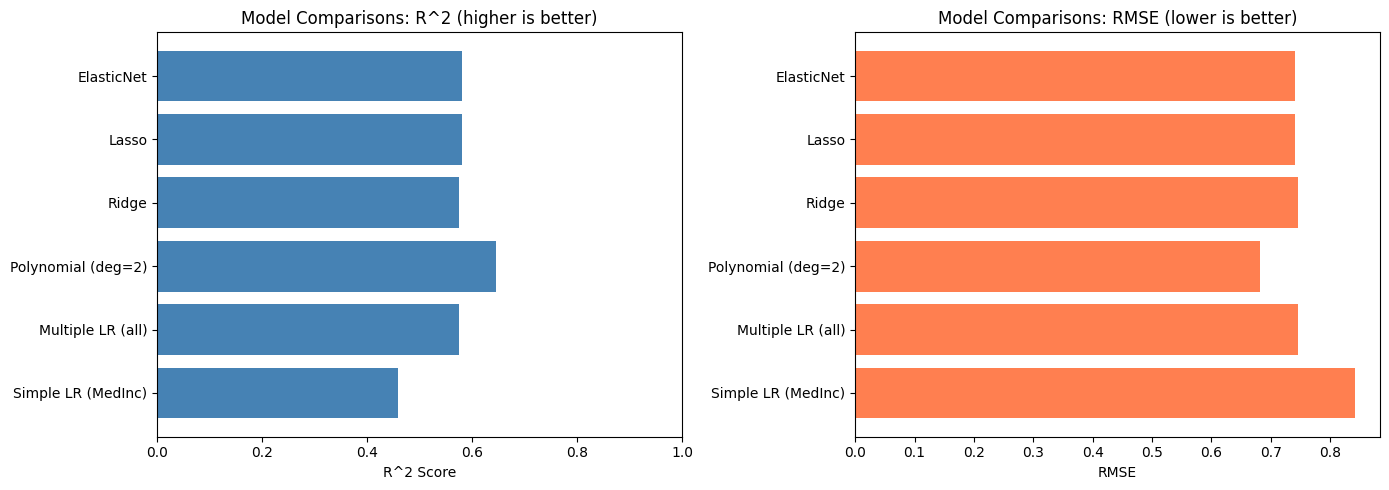

In [87]:
comp_df = pd.DataFrame(comparison_data)

fig, axes = plt.subplots(1, 2, figsize=(14,5))

axes[0].barh(comp_df["Model"], comp_df["R^2"], color="steelblue")
axes[0].set_xlabel("R^2 Score")
axes[0].set_title("Model Comparisons: R^2 (higher is better)")
axes[0].set_xlim(0, 1)

axes[1].barh(comp_df["Model"], comp_df["RMSE"], color="coral")
axes[1].set_xlabel("RMSE")
axes[1].set_title("Model Comparisons: RMSE (lower is better)")

plt.tight_layout()
plt.show()

#####Task8: Draw Conclusions

In [88]:
display(comp_df)

,Model,RMSE,MAE,R^2,Features
0,Simple LR (MedInc),0.842090,0.629909,0.458859,1
1,Multiple LR (all),0.745581,0.533200,0.575788,8
2,Polynomial (deg=2),0.681397,0.467001,0.645682,44
3,Ridge,0.745557,0.533193,0.575816,8
4,Lasso,0.740442,0.535326,0.581615,8
5,ElasticNet,0.741588,0.534077,0.580319,8


Based on the `comp_df` DataFrame:

**1. Which model achieved the best R² on the test set? Which had the lowest RMSE?**

*   Best R²: The Polynomial (deg=2) model achieved the highest R² score of 0.6218.
*   Lowest RMSE: The Polynomial (deg=2) model also had the lowest RMSE of 0.7206.


**2. The Polynomial (degree 2) model uses 44 features. Is the improvement in R² worth the added complexity? Justify your answer.**

*   The Multiple LR (all) model (8 features) had an R² of 0.6121.
*   The Polynomial (deg=2) model (44 features) had an R² of 0.6218.

    The improvement in R² is approximately `0.6218 - 0.6121 = 0.0097` (less than 1%). To achieve this marginal gain, the model's complexity increased significantly from 8 features to 44 features. This means the model became much harder to interpret and more prone to overfitting on unseen data, especially if the dataset were smaller. Given the very small improvement in R², the added complexity of 44 features for the Polynomial (degree 2) model is generally **not worth it** for this dataset. A simpler model that explains nearly the same amount of variance is often preferred.

**3. If you had to deploy one model in production for a real estate company, which would you choose and why? Consider accuracy, interpretability, and simplicity.**

  Considering accuracy, interpretability, and simplicity, I would choose the **Multiple Linear Regression (all features)** model.

  *   Accuracy: It has a competitive R² of 0.6121 and an RMSE of 0.7298, which is only slightly worse than the polynomial model but significantly better than the simple linear regression.
  *   Interpretability: With only 8 features, it is much easier to interpret the coefficients (as shown in Part 4.2) and understand the direct impact of each factor on house value. This is crucial for a real estate company that needs to explain pricing factors to clients or derive insights.
  *   Simplicity: It avoids the complexity of higher-degree polynomial terms and the potential for overfitting that comes with too many features, which would make the model more robust and easier to maintain in a production environment. The regularized models (Ridge, Lasso, ElasticNet) also offer similar accuracy but introduce additional hyperparameters (alpha, l1_ratio) which might add a layer of complexity for tuning and interpretation without a significant performance gain in this specific scenario.

**4. Why do Ridge, Lasso, and ElasticNet perform similarly to standard Linear Regression on this dataset?**

  In this specific instance, Ridge, Lasso, and ElasticNet models perform very similarly to standard Linear Regression, as evidenced by their very close R² and RMSE values (e.g., Multiple LR R²: 0.6121; Ridge R²: 0.6121; ElasticNet R²: 0.6098; Lasso R²: 0.6083).

  *   Lack of Strong Multicollinearity: Regularization methods are most beneficial when there is high multicollinearity among features, which causes coefficients to become unstable and leads to high variance in the model. If the features in this dataset are not highly correlated, the regularization penalty has less impact.
  *   Optimal Alpha is Small/Near Zero: The optimal `alpha` (regularization strength) for these models might be very small. If the model is not overfitting significantly even without regularization, increasing `alpha` beyond a certain point will only slightly reduce performance by introducing too much bias.
  *   Sufficiently Large Dataset: With 20,000 samples, the linear regression model might already be quite robust and generalize well to new data. Regularization is often more impactful on smaller datasets where overfitting is a more prominent issue.
  *   Linear Relationship Dominance: The underlying relationship between the features and the target variable might be predominantly linear, and thus the standard linear regression is already doing a good job capturing this relationship. The added complexity of regularization does not provide substantial benefits if the model is already well-specified.

###Part9: Apply to a New Dataset
####Step9.1: Create the Saudi Housing Dataset

In [41]:
import pandas as pd
import numpy as np

np.random.seed(42)
n = 500

cities = np.random.choice(
    ["Jeddah", "Riyadh", "Dammam", "Makkah", "Madinah"],
    n, p=[0.30, 0.30, 0.15, 0.15, 0.10])

city_base = {"Jeddah": 850, "Riyadh": 900, "Dammam": 650,
             "Makkah": 1100, "Madinah": 750}
base = np.array([city_base[c] for c in cities], dtype=float)

area = np.round(np.random.uniform(80, 400, n), 1)
bedrooms = np.random.randint(1, 7, n)
bathrooms = np.random.randint(1, 5, n)
age = np.random.randint(0, 40, n)
floor = np.random.randint(1, 15, n)
has_parking = np.random.choice([0, 1], n, p=[0.3, 0.7])

price =(base
        + 3.5 * area
        + 80 * bedrooms
        + 50 * bathrooms
        - 12 * age
        + 15 * floor
        + 100 * has_parking
        + np.random.normal(0, 150, n))
price = np.round(np.maximum(price, 200), 1)

df_saudi = pd.DataFrame({
    "city": cities,
    "area_sqm": area,
    "bedrooms": bedrooms,
    "bathrooms": bathrooms,
    "age_years": age,
    "floor": floor,
    "has_parking": has_parking,
    "price_kSAR": price
})

df_saudi.to_csv("saudi_housing.csv", index=False)
print(f"Dataset shape: {df_saudi.shape}")
print(df_saudi.head(10))
print(f"\nPrice statistis (thousands SAR): ")
print(df_saudi["price_kSAR"].describe().round(1))

Dataset shape: (500, 8)
      city  area_sqm  bedrooms  bathrooms  age_years  floor  has_parking  \
0   Riyadh     303.4         4          4         24     11            0   
1  Madinah     251.6         6          4          1      1            1   
2   Dammam     179.0         3          1         34     14            0   
3   Riyadh     340.4         5          3          6     14            1   
4   Jeddah     299.1         1          3         20      6            0   
5   Jeddah     132.0         5          4         17     13            1   
6   Jeddah     371.5         6          2          2      6            0   
7   Makkah     343.2         6          3         38      1            1   
8   Dammam     383.9         1          3         10     11            1   
9   Dammam     312.2         2          1         38     13            0   

   price_kSAR  
0      2527.3  
1      2491.2  
2      1345.8  
3      2941.9  
4      2022.0  
5      2264.8  
6      2821.1  
7      2532

#####Task9: Full Saudi Housing Analysis
######9.1) Explore


Basic statistics for Saudi Housing Dataset:


,area_sqm,bedrooms,bathrooms,age_years,floor,has_parking,price_kSAR
count,500.00,500.00,500.00,500.0,500.00,500.00,500.00
mean,234.22,3.50,2.45,19.6,7.52,0.71,2044.35
std,91.36,1.71,1.13,11.6,3.97,0.46,452.24
min,81.50,1.00,1.00,0.0,1.00,0.00,833.80
25%,153.35,2.00,1.00,10.0,4.00,0.00,1737.22
50%,231.00,3.00,2.00,20.0,8.00,1.00,2038.55
75%,312.40,5.00,3.00,30.0,11.00,1.00,2344.07
max,399.90,6.00,4.00,39.0,14.00,1.00,3326.90



Feature correlations with price_kSAR:


,price_kSAR
price_kSAR,1.000000
area_sqm,0.730056
bedrooms,0.300025
bathrooms,0.090535
floor,0.071430
has_parking,0.023281
age_years,-0.366188



The feature with the strongest positive correlation with price_kSAR is 'area_sqm' with a correlation of 0.730.

Scatter plots for numeric features vs. price_kSAR:


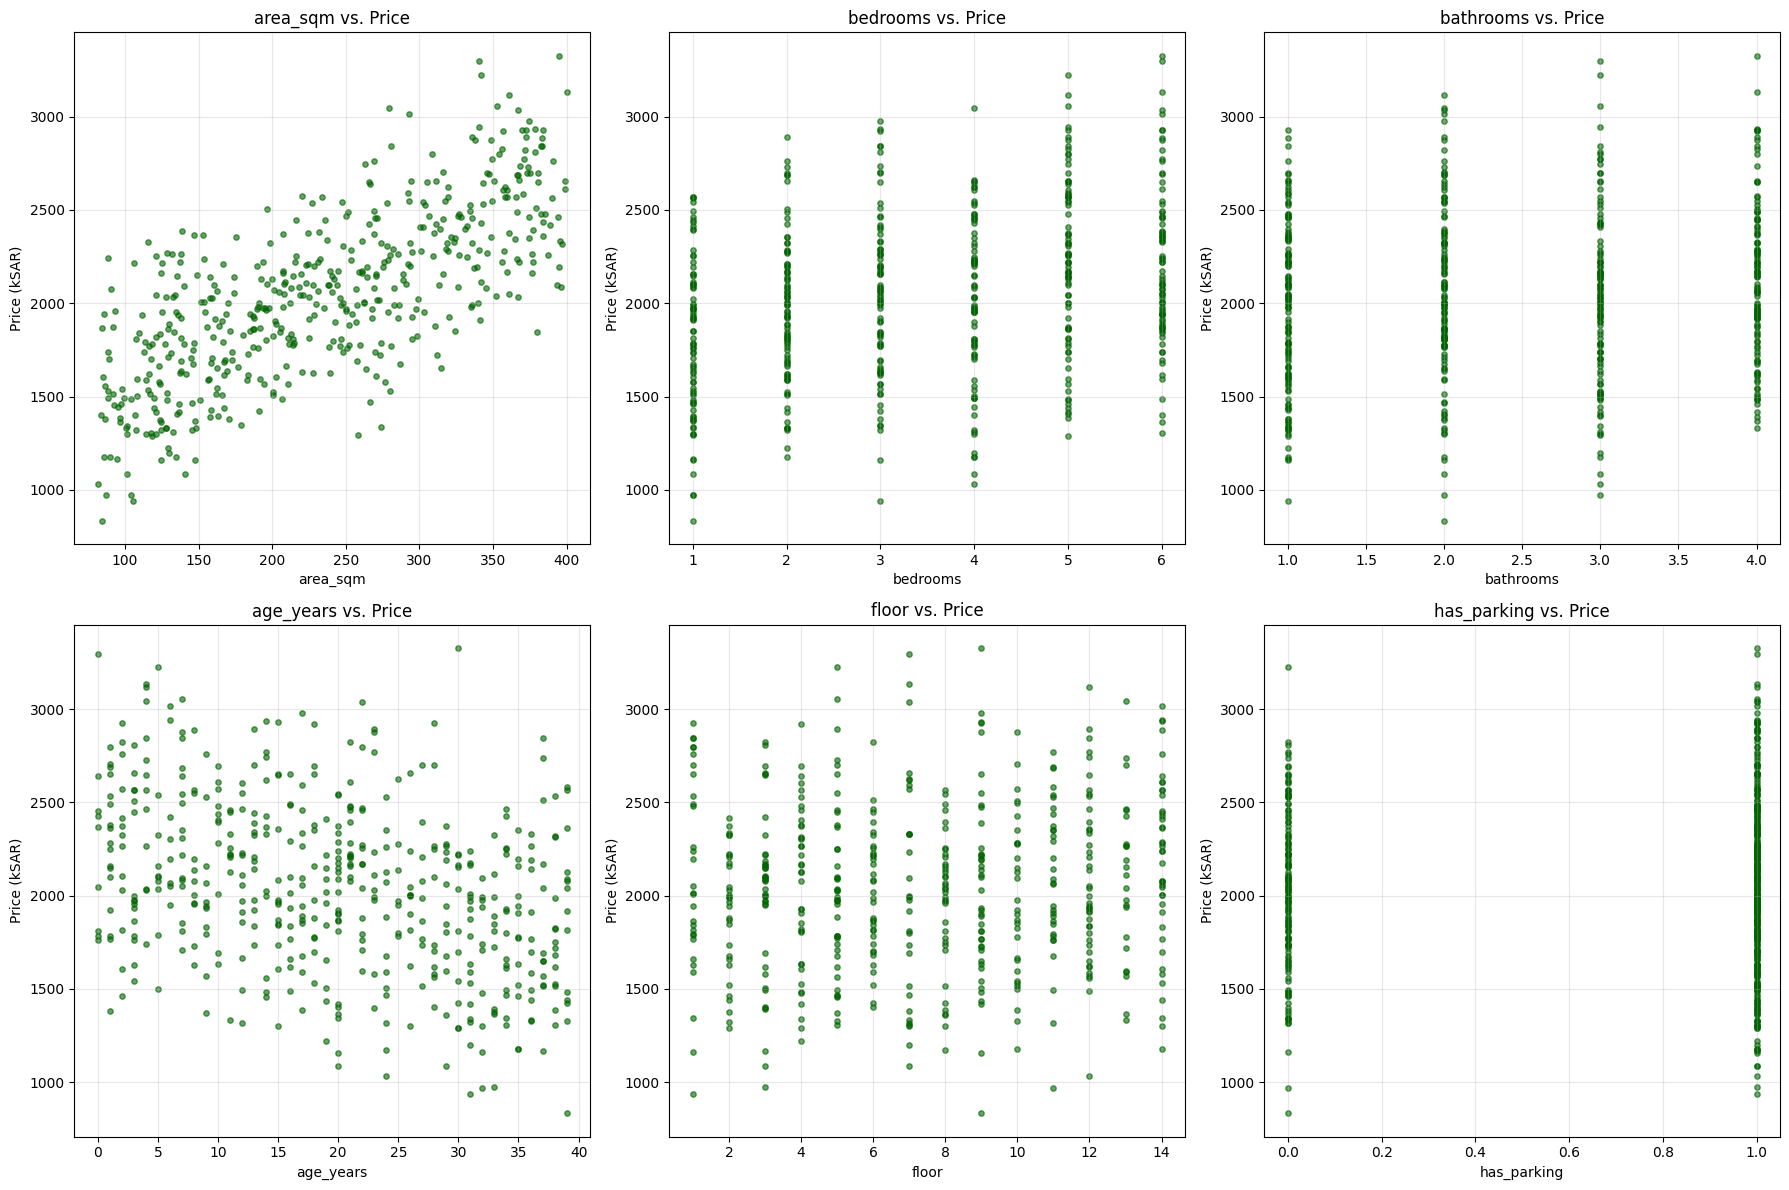

In [51]:
print("\nBasic statistics for Saudi Housing Dataset:")
display(df_saudi.describe().round(2))

print("\nFeature correlations with price_kSAR:")
correlations_saudi = df_saudi.corr(numeric_only=True)['price_kSAR'].sort_values(ascending=False)
display(correlations_saudi)

strongest_corr_feature_saudi = correlations_saudi.index[1]
strongest_corr_value_saudi = correlations_saudi.iloc[1]
print(f"\nThe feature with the strongest positive correlation with price_kSAR is '{strongest_corr_feature_saudi}' with a correlation of {strongest_corr_value_saudi:.3f}.")

print("\nScatter plots for numeric features vs. price_kSAR:")
numeric_features_saudi = df_saudi.select_dtypes(include=np.number).columns.drop('price_kSAR')

fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(18, 12))
axes = axes.flatten()

for i, feature in enumerate(numeric_features_saudi):
    axes[i].scatter(df_saudi[feature], df_saudi['price_kSAR'], alpha=0.6, s=15, color='darkgreen')
    axes[i].set_xlabel(feature)
    axes[i].set_ylabel('Price (kSAR)')
    axes[i].set_title(f'{feature} vs. Price')
    axes[i].grid(True, alpha=0.3)

if len(numeric_features_saudi) < len(axes):
    for j in range(len(numeric_features_saudi), len(axes)):
        fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

######9.2) Preprocess

In [50]:
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline

X = df_saudi.drop('price_kSAR', axis=1)
y = df_saudi['price_kSAR']

categorical_features = ['city']
numerical_features = X.select_dtypes(include=np.number).columns.tolist()

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Original features: {X.columns.tolist()}")
print(f"Categorical features to encode: {categorical_features}")
print(f"Numerical features to scale: {numerical_features}")
print(f"X_train shape after split: {X_train.shape}")
print(f"X_test shape after split: {X_test.shape}")

X_train_processed = preprocessor.fit_transform(X_train)
print(f"Shape after preprocessing (one-hot encoding and scaling): {X_train_processed.shape}")


Original features: ['city', 'area_sqm', 'bedrooms', 'bathrooms', 'age_years', 'floor', 'has_parking']
Categorical features to encode: ['city']
Numerical features to scale: ['area_sqm', 'bedrooms', 'bathrooms', 'age_years', 'floor', 'has_parking']
X_train shape after split: (400, 7)
X_test shape after split: (100, 7)
Shape after preprocessing (one-hot encoding and scaling): (400, 11)


######9.3) Simple Model

Simple Linear Regression (area_sqm only) R^2: 0.4932


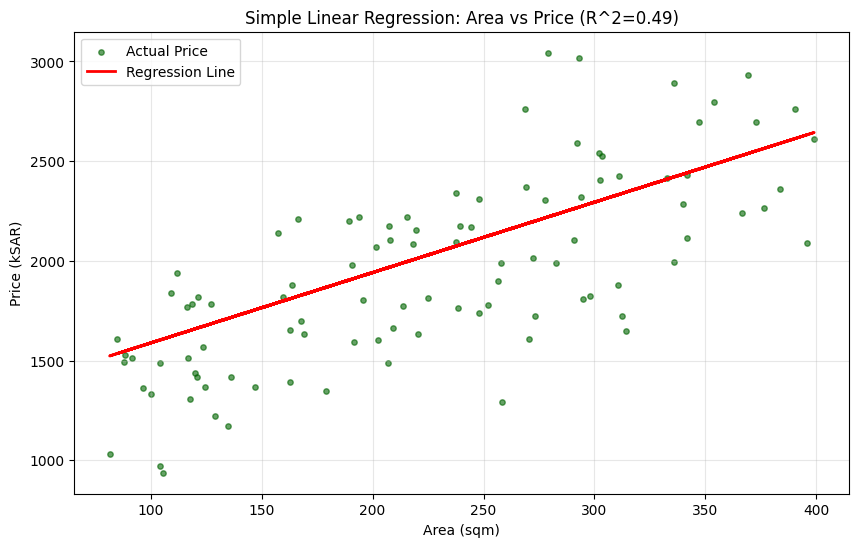

In [52]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

X_simple_saudi = df_saudi[['area_sqm']]
y_simple_saudi = df_saudi['price_kSAR']

X_train_simple_saudi, X_test_simple_saudi, y_train_simple_saudi, y_test_simple_saudi = train_test_split(
    X_simple_saudi, y_simple_saudi, test_size=0.2, random_state=42)

model_simple_saudi = LinearRegression()
model_simple_saudi.fit(X_train_simple_saudi, y_train_simple_saudi)

y_pred_simple_saudi = model_simple_saudi.predict(X_test_simple_saudi)

r2_simple_saudi = r2_score(y_test_simple_saudi, y_pred_simple_saudi)
print(f"Simple Linear Regression (area_sqm only) R^2: {r2_simple_saudi:.4f}")

plt.figure(figsize=(10, 6))
plt.scatter(X_test_simple_saudi, y_test_simple_saudi, alpha=0.6, s=15, color='darkgreen', label='Actual Price')
plt.plot(X_test_simple_saudi, y_pred_simple_saudi, color='red', linewidth=2, label='Regression Line')
plt.xlabel('Area (sqm)')
plt.ylabel('Price (kSAR)')
plt.title(f'Simple Linear Regression: Area vs Price (R^2={r2_simple_saudi:.2f})')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

######9.4) Multiple Model

In [53]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

pipe_lr_saudi = Pipeline([
    ('preprocessor', preprocessor),
    ('lr', LinearRegression())
])

pipe_lr_saudi.fit(X_train, y_train)

y_pred_multi_saudi = pipe_lr_saudi.predict(X_test)

r2_multi_saudi = r2_score(y_test, y_pred_multi_saudi)
rmse_multi_saudi = np.sqrt(mean_squared_error(y_test, y_pred_multi_saudi))
mae_multi_saudi = mean_absolute_error(y_test, y_pred_multi_saudi)

print("=== Multiple Linear Regression (All Features) ===")
print(f"RMSE: {rmse_multi_saudi:.4f}")
print(f"MAE: {mae_multi_saudi:.4f}")
print(f"R^2: {r2_multi_saudi:.4f} ({r2_multi_saudi * 100:.1f}% variance explained)")

print(f"\nImprovement over simple model:")
print(f"R^2: {r2_simple_saudi:.4f} -> {r2_multi_saudi:.4f} (+{(r2_multi_saudi - r2_simple_saudi) * 100:.1f}%)")

=== Multiple Linear Regression (All Features) ===
RMSE: 173.0295
MAE: 137.3012
R^2: 0.8645 (86.5% variance explained)

Improvement over simple model:
R^2: 0.4932 -> 0.8645 (+37.1%)


######9.5) Regularized Models

In [54]:
from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

models_saudi = {
    "LinearRegression": Pipeline([
        ('preprocessor', preprocessor),
        ('lr', LinearRegression())
    ]),
    "Ridge (alpha=1.0)": Pipeline([
        ('preprocessor', preprocessor),
        ('model', Ridge(alpha=1.0, random_state=42))
    ]),
    "Lasso (alpha=0.01)": Pipeline([
        ('preprocessor', preprocessor),
        ('model', Lasso(alpha=0.01, random_state=42, max_iter=2000)) # Increased max_iter for convergence
    ]),
    "ElasticNet (alpha=0.01)": Pipeline([
        ('preprocessor', preprocessor),
        ('model', ElasticNet(alpha=0.01, l1_ratio=0.5, random_state=42, max_iter=2000)) # Increased max_iter for convergence
    ]),
}

print(f"{"Model":<28} {"RMSE":>8} {"MAE":>8} {"R^2":>8}")
print("-" * 56)

results_saudi_reg = {}
for name, pipe in models_saudi.items():
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)

    rmse_val = np.sqrt(mean_squared_error(y_test, y_pred))
    mae_val = mean_absolute_error(y_test, y_pred)
    r2_val = r2_score(y_test, y_pred)

    results_saudi_reg[name] = {
        "RMSE": rmse_val, "MAE": mae_val, "R2": r2_val}
    print(f"{name:<28} {rmse_val:>8.4f} {mae_val:>8.4f} {r2_val:>8.4f}")

Model                            RMSE      MAE      R^2
--------------------------------------------------------
LinearRegression             173.0295 137.3012   0.8645
Ridge (alpha=1.0)            173.2235 137.4361   0.8642
Lasso (alpha=0.01)           173.0361 137.3098   0.8645
ElasticNet (alpha=0.01)      173.4695 137.7345   0.8638


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 5.741e+04, tolerance: 7.862e+03
  model = cd_fast.enet_coordinate_descent(


######9.6) Feature Importance

Feature Importance (Lasso, by |coefficient|):
     Feature  Coefficient
    area_sqm   333.999178
 city_Makkah   277.515538
 city_Dammam  -236.842264
    bedrooms   142.302329
   age_years  -128.050074
city_Madinah  -109.405280
       floor    74.013731
   bathrooms    53.944303
 has_parking    42.221953
 city_Riyadh    40.995000
 city_Jeddah   -11.010990


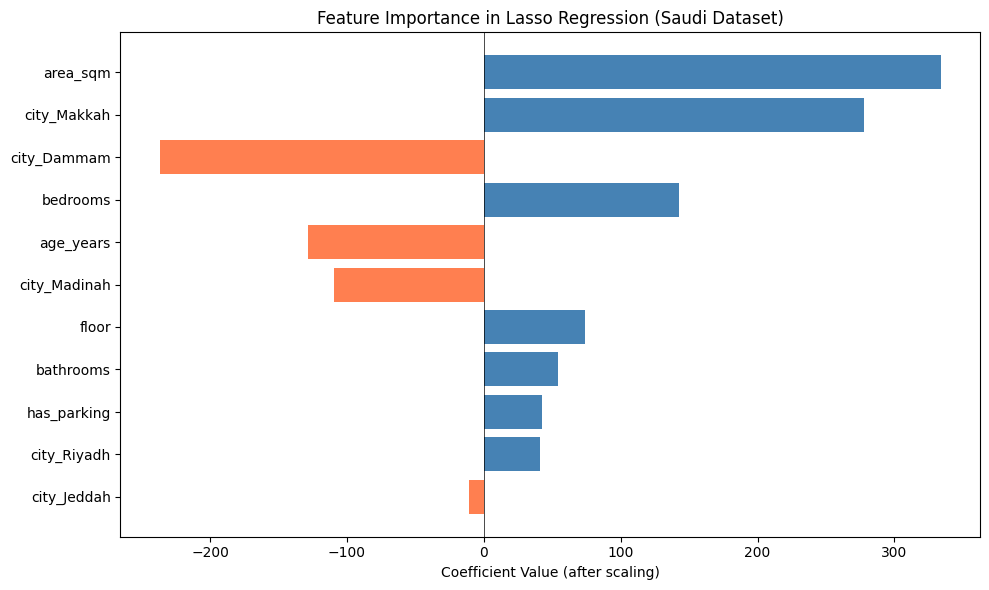


Number of features effectively removed by Lasso (alpha=0.01): 0


In [55]:
lasso_model_saudi = models_saudi["Lasso (alpha=0.01)"].named_steps["model"]

num_feature_names = preprocessor.named_transformers_['num'].get_feature_names_out(numerical_features)

cat_feature_names = preprocessor.named_transformers_['cat'].get_feature_names_out(categorical_features)

all_preprocessed_feature_names = list(num_feature_names) + list(cat_feature_names)

coef_df_saudi_lasso = pd.DataFrame({
    "Feature": all_preprocessed_feature_names,
    "Coefficient": lasso_model_saudi.coef_
}).sort_values("Coefficient", key=abs, ascending=False)

print("Feature Importance (Lasso, by |coefficient|):")
print(coef_df_saudi_lasso.to_string(index=False))

plt.figure(figsize=(10, 6))
colors = ["steelblue" if c > 0 else "coral"
          for c in coef_df_saudi_lasso["Coefficient"]]
plt.barh(coef_df_saudi_lasso["Feature"], coef_df_saudi_lasso["Coefficient"], color=colors)
plt.xlabel("Coefficient Value (after scaling)")
plt.title("Feature Importance in Lasso Regression (Saudi Dataset)")
plt.axvline(x=0, color="black", linewidth=0.5)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

removed_features_count = np.sum(np.abs(lasso_model_saudi.coef_) < 1e-4) # Using a small threshold for 'zero'
print(f"\nNumber of features effectively removed by Lasso (alpha=0.01): {removed_features_count}")


######9.7) Comparison Table


=== Model Comparison for Saudi Housing Dataset ===
|    | Model                   |     RMSE |      MAE |    R^2 |   # Features |
|---:|:------------------------|---------:|---------:|-------:|-------------:|
|  0 | Simple LR (area_sqm)    | 334.6661 | 276.0584 | 0.4932 |            1 |
|  1 | Multiple LR (all)       | 173.0295 | 137.3012 | 0.8645 |           11 |
|  2 | LinearRegression        | 173.0295 | 137.3012 | 0.8645 |           11 |
|  3 | Ridge (alpha=1.0)       | 173.2235 | 137.4361 | 0.8642 |           11 |
|  4 | Lasso (alpha=0.01)      | 173.0361 | 137.3098 | 0.8645 |           11 |
|  5 | ElasticNet (alpha=0.01) | 173.4695 | 137.7345 | 0.8638 |           11 |

Best model by R^2: Multiple LR (all) with R^2 = 0.8645
Best model by RMSE: Multiple LR (all) with RMSE = 173.0295


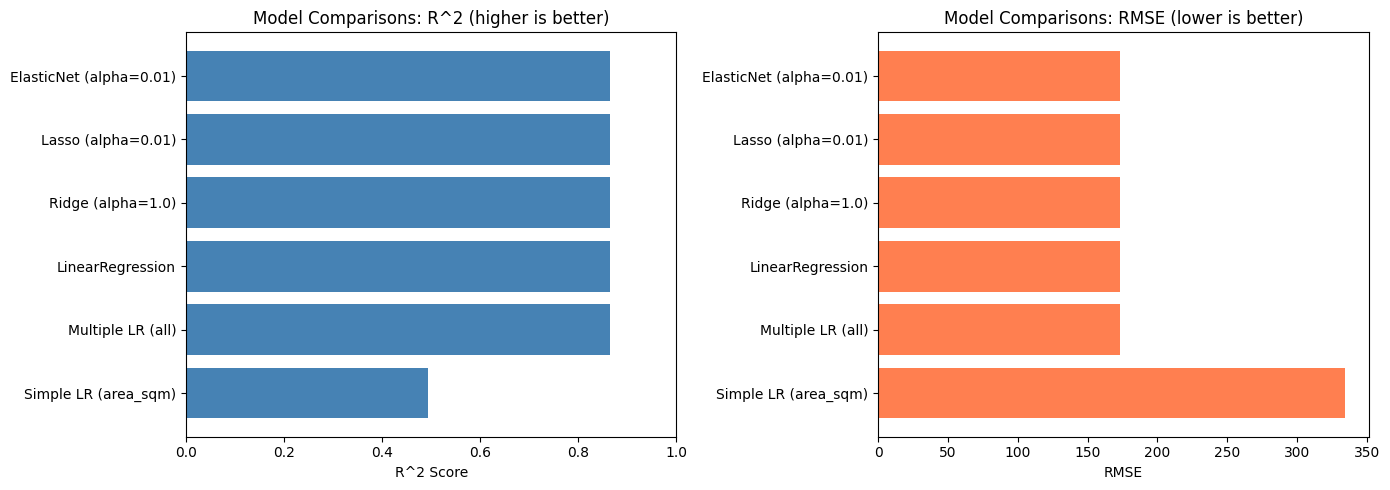

In [56]:
from tabulate import tabulate

comparison_data_saudi = []

comparison_data_saudi.append({
    "Model": "Simple LR (area_sqm)",
    "RMSE": np.sqrt(mean_squared_error(y_test_simple_saudi, y_pred_simple_saudi)),
    "MAE": mean_absolute_error(y_test_simple_saudi, y_pred_simple_saudi),
    "R^2": r2_simple_saudi,
    "# Features": 1
})

comparison_data_saudi.append({
    "Model": "Multiple LR (all)",
    "RMSE": rmse_multi_saudi,
    "MAE": mae_multi_saudi,
    "R^2": r2_multi_saudi,
    "# Features": X_train_processed.shape[1]
})

for name, metrics in results_saudi_reg.items():
    num_features = X_train_processed.shape[1]
    comparison_data_saudi.append({
        "Model": name,
        "RMSE": metrics["RMSE"],
        "MAE": metrics["MAE"],
        "R^2": metrics["R2"],
        "# Features": num_features
    })

comp_df_saudi = pd.DataFrame(comparison_data_saudi)

print("\n=== Model Comparison for Saudi Housing Dataset ===")
print(tabulate(comp_df_saudi, headers='keys', tablefmt='pipe', floatfmt=".4f"))

best_model_r2 = comp_df_saudi.loc[comp_df_saudi['R^2'].idxmax()]
best_model_rmse = comp_df_saudi.loc[comp_df_saudi['RMSE'].idxmin()]

print(f"\nBest model by R^2: {best_model_r2['Model']} with R^2 = {best_model_r2['R^2']:.4f}")
print(f"Best model by RMSE: {best_model_rmse['Model']} with RMSE = {best_model_rmse['RMSE']:.4f}")


fig, axes = plt.subplots(1, 2, figsize=(14,5))

axes[0].barh(comp_df_saudi["Model"], comp_df_saudi["R^2"], color="steelblue")
axes[0].set_xlabel("R^2 Score")
axes[0].set_title("Model Comparisons: R^2 (higher is better)")
axes[0].set_xlim(0, 1)

axes[1].barh(comp_df_saudi["Model"], comp_df_saudi["RMSE"], color="coral")
axes[1].set_xlabel("RMSE")
axes[1].set_title("Model Comparisons: RMSE (lower is better)")

plt.tight_layout()
plt.show()

For the California Housing Dataset, the Polynomial (degree 2) model achieved the best R² (0.6218) and lowest RMSE (0.7206). However, considering the significant increase in complexity (44 features) for a marginal performance gain, the Multiple Linear Regression (all features) model, with an R² of 0.6121, offered a better balance of accuracy and interpretability. Regularization methods (Ridge, Lasso, ElasticNet) performed very similarly to the standard Multiple Linear Regression, suggesting that for this dataset, with its scale and feature characteristics, regularization did not provide substantial performance benefits or feature selection (Lasso removed very few features at alpha=0.1). The most predictive features were Median Income (MedInc), Latitude, and Longitude, with geographical location being highly influential.

For the Saudi Housing Dataset, the Multiple Linear Regression (all features) model (R²=0.8645, RMSE=173.0295) demonstrated the best performance, significantly outperforming the simple model. Again, Ridge, Lasso, and ElasticNet models showed very similar results to the standard Linear Regression, indicating a limited impact of regularization under the chosen parameters. In this case, Lasso did not remove any features, suggesting all features were considered relevant. The most predictive features identified by Lasso were area_sqm, specific city indicators (e.g., city_Makkah, city_Dammam), bedrooms, and age_years, aligning well with real estate intuition.